In [39]:
import torch
from torch.nn.functional import threshold

from models import ou_model, logistic_model, simulate, plot_traj_set

0.010000000000000002

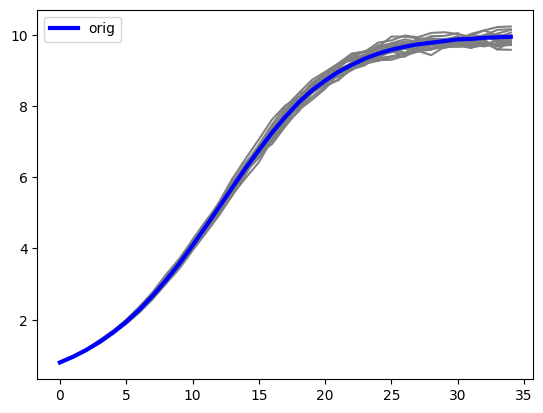

In [47]:
# logistic growth  process
# X_{t+1} = X_t + r * X_t * (1 - X_t/k)  + X_t *sqrt(k)*sigma*ep;  eps~normal(0,1)

time = 35
#fast convergence to x=2, with little noise
params = {'time': time,      # time steps
            'init_x':1.0,  # initial x
            'r': 0.18,        #
            'k': 10.0,       #
            'sigma': 0.1}

#slower convergence to x=2, higher variance
params2 = {'time': time,      # time steps
            'init_x':0.8,  # initial x
            'r': 0.22,        #
            'k': 10.0,        #
            'sigma': 0.1}


n_trajs = 10_000
trajs = simulate(logistic_model, 100, params2)

plot_traj_set(trajs, single_traj=20, color='blue', label='orig')

# model is using as std sigma*sigma
params2['sigma']**2

In [68]:
# sometimes[0,b] historically |x - 10|  <= 1
threshold = 9.75
#atomic proposition
atom = (trajs > threshold).int()

# historically [t,T] atom same as globally atom
historically = torch.flip(torch.cumprod(torch.flip(atom, dims=[1]), dim=1), dims=[1])
#eventually[0,b]  globally atom
sometimes = torch.cummax(historically, dim=1).values

truth_probability = sometimes.float().mean(dim=0)
#b = 30
truth_probability[-1]

tensor(0.8600, dtype=torch.float32)

DeGAS section

In [61]:
import sys
import os
sys.path.insert(0, os.path.abspath('../../../src'))

# import module optimization to use DeGAS
from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

### Trajectory

In [62]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('logistic.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# cfg represents now the smoothed program
# The cfg can be explored using the dictionary cfg.node_list

cfg.node_list

{'entry': EntryNode<>,
 'state0': StateNode<state0,None,currX=0.8,smoothed:currX=0.8+ gm([1.], [0.], [0.0010000000])>,
 'loop0': LoopNode<loop0>,
 'state1': StateNode<state1,True,X[i]=currX,smoothed:X[i]=currX+ gm([1.], [0.], [0.0010000000])>,
 'state2': StateNode<state2,None,xSquare=currX*currX>,
 'state3': StateNode<state3,None,noise=gm([1.0],[0.000000],[0.100000])>,
 'state4': StateNode<state4,None,xNoise=currX*noise>,
 'state5': StateNode<state5,None,newX=1.22*currX-0.022*xSquare+xNoise,smoothed:newX=1.22*currX-0.022*xSquare+xNoise+ gm([1.], [0.], [0.0010000000])>,
 'state6': StateNode<state6,None,currX=newX,smoothed:currX=newX+ gm([1.], [0.], [0.0010000000])>,
 'state7': StateNode<state7,False,skip>,
 'exit': ExitNode<>}

In [63]:
#run SOGA
output_dist = start_SOGA(cfg)

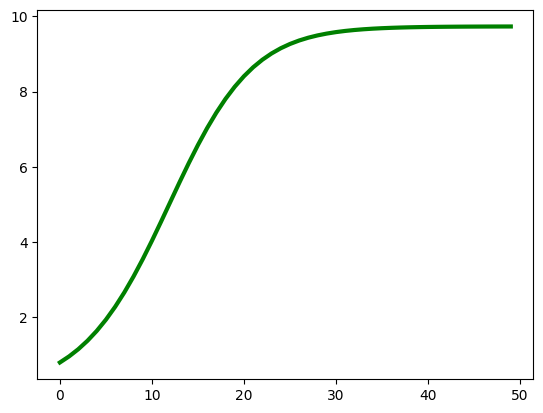

In [64]:
T = 50
#output_dist
plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

### Boolean

In [75]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('logistic-bool.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# cfg represents now the smoothed program
# The cfg can be explored using the dictionary cfg.node_list

cfg.node_list

{'entry': EntryNode<>,
 'state0': StateNode<state0,None,currX=0.8,smoothed:currX=0.8+ gm([1.], [0.], [0.0010000000])>,
 'state1': StateNode<state1,None,phi=0,smoothed:phi=0+ gm([1.], [0.], [0.0010000000])>,
 'loop0': LoopNode<loop0>,
 'state2': StateNode<state2,True,xSquare=currX*currX>,
 'state3': StateNode<state3,None,noise=gm([1.0],[0.000000],[0.010000])>,
 'state4': StateNode<state4,None,xNoise=currX*noise>,
 'state5': StateNode<state5,None,newX=1.22*currX-0.022*xSquare+xNoise,smoothed:newX=1.22*currX-0.022*xSquare+xNoise+ gm([1.], [0.], [0.0010000000])>,
 'test0': TestNode<test0,newX>9.75>,
 'state6': StateNode<state6,True,phi=1,smoothed:phi=1+ gm([1.], [0.], [0.0010000000])>,
 'state7': StateNode<state7,False,phi=0,smoothed:phi=0+ gm([1.], [0.], [0.0010000000])>,
 'merge0': MergeNode<merge0>,
 'state8': StateNode<state8,None,currX=newX,smoothed:currX=newX+ gm([1.], [0.], [0.0010000000])>,
 'state9': StateNode<state9,False,skip>,
 'exit': ExitNode<>}

In [77]:
#run SOGA
output_dist = start_SOGA(cfg)
output_dist.gm.n_comp()

14237

In [78]:
phi_idx = output_dist.var_list.index('phi')
output_dist.gm.mean()[phi_idx]

tensor(0.9003)